In [1]:
from IPython.display import HTML

import urllib.request

# add RTB examples folder to the path
import sys, os.path
import roboticstoolbox as rtb
import RVC3
# sys.path.append(os.path.join(rtb.__path__[0], 'examples'))
sys.path.append(os.path.join(RVC3.__path__[0], 'examples'))

# standard imports
import numpy as np
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *
from roboticstoolbox import quintic, trapezoidal, mtraj, mstraj, xplot, ctraj

%matplotlib widget

### Estimating Orientation

In [2]:
import imu_data

true = imu_data.tumble()

In [3]:
orientation = UnitQuaternion() # identity quaternion

In [4]:
orientation = UnitQuaternion()

for k in range(len(true.t) - 1):
    dt = true.t[k+1] - true.t[k]
    w = true.omega_true[k]

    next_orientation = (
        orientation[-1]
        @ UnitQuaternion.EulerVec(w * dt)
    )

    orientation.append(next_orientation)
len(orientation)

400

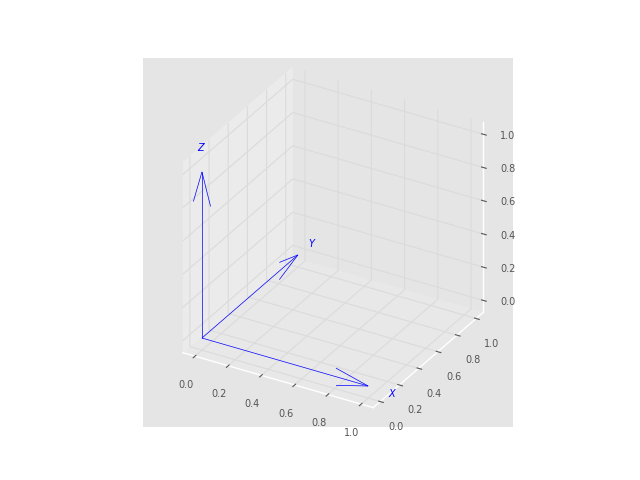

In [5]:
orientation.animate(time=true.t)

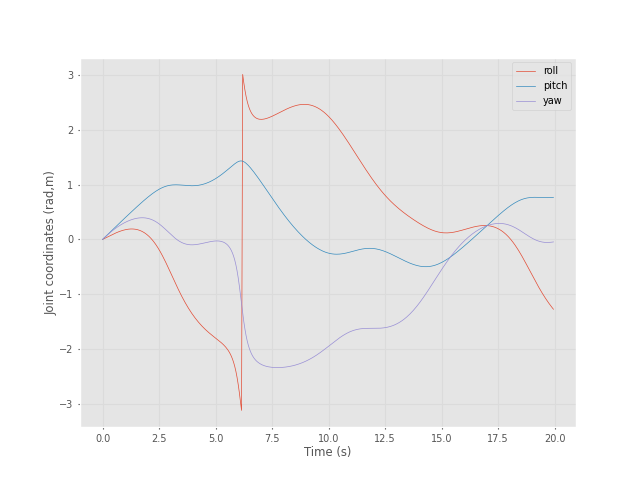

[<Axes: xlabel='Time (s)', ylabel='Joint coordinates (rad,m)'>]

In [6]:
xplot(true.t, orientation.rpy(), labels="roll pitch yaw")